<a href="https://colab.research.google.com/github/Emchi26/2do-Challenge---Alura-Latam/blob/main/TelecomX_LATAM_AaronCapellino.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracción

In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
data = pd.read_json(url)
data.head()

#🔧 Transformación

## **Analizando en primer instancia**

In [ ]:
data.info()

In [ ]:
data.dtypes

In [ ]:
data.shape

In [ ]:
data.sample(10)

## **Normalizando la data**

In [ ]:
df_costumer = pd.json_normalize(data["customer"])
df_costumer.sample(10)

In [ ]:
df_phone = pd.json_normalize(data["phone"])
df_phone.sample(10)

In [ ]:
df_internet = pd.json_normalize(data["internet"])
df_internet.sample(10)

In [ ]:
df_account = pd.json_normalize(data["account"])
df_account.sample(10)

In [ ]:
# Unire todo en un solo DF para mejor manejo de datos

data_norm = pd.concat(
    [data[['customerID', 'Churn']],  # columnas originales
     df_costumer,
     df_phone,
     df_internet,
     df_account],
    axis=1
)

In [ ]:
data_norm["Charges.Total"].sample(10)

In [ ]:
data_norm.sample(10)

## **Manejo de inconsistencias**

In [ ]:
data_norm.columns = data_norm.columns.str.lower().str.replace(".", "_")
data_norm.head()

In [ ]:
import numpy as np

In [ ]:
data_norm["Charges.Total"] = data_norm["Charges.Total"].astype(str).str.strip().replace("",None)

In [ ]:
data_norm["Charges.Total"] = data_norm["Charges.Total"].astype(np.float64)

In [ ]:
col_str = list(data_norm.select_dtypes(include="object").columns)
col_str

In [ ]:
data_norm[col_str] = data_norm[col_str].applymap(lambda x: x.lower())
data_norm[col_str].sample(10)

In [ ]:
data_norm['onlinebackup'].unique()

In [ ]:
data_norm['onlinesecurity'].unique()

In [ ]:
data_norm.sample(10)

In [ ]:
data_norm["multiplelines"]

In [ ]:
data_norm["multiplelines"] = data_norm["multiplelines"].replace("no phone service", "no")

In [ ]:
data_norm["multiplelines"]

In [ ]:
col_internet = ["onlinesecurity","onlinebackup","deviceprotection","techsupport","streamingtv","streamingmovies"]

In [ ]:
data_norm[col_internet] = data_norm[col_internet].replace("no internet service", "no")

In [ ]:
data_norm.sample(10)

In [ ]:
data_norm["paymentmethod"] = data_norm["paymentmethod"].str.replace('\(|\)',"",regex=True)

In [ ]:
data_norm.sample(10)

In [ ]:
data_norm["charges_total"].fillna(data_norm["charges_monthly"] * 12, inplace=True)

In [ ]:
data_norm["charges_total"].sample(10)

## **Columna de cuentas diarias**

Ahora que los datos están limpios, es momento de crear la columna "Cuentas_Diarias". Utiliza la facturación mensual para calcular el valor diario, proporcionando una visión más detallada del comportamiento de los clientes a lo largo del tiempo.

📌 Esta columna te ayudará a profundizar en el análisis y a obtener información valiosa para las siguientes etapas.

In [ ]:
data_norm.sample(5)

In [ ]:
data_norm["charges_daily"] = (data_norm["charges_monthly"] / 30).round(2)
data_norm.sample(5)

## **Estandarización y transformación de datos (opcional)**

La estandarización y transformación de datos es una etapa opcional, pero altamente recomendada, ya que busca hacer que la información sea más consistente, comprensible y adecuada para el análisis. Durante esta fase, por ejemplo, puedes convertir valores textuales como "Sí" y "No" en valores binarios (1 y 0), lo que facilita el procesamiento matemático y la aplicación de modelos analíticos.

Además, traducir o renombrar columnas y datos hace que la información sea más accesible y fácil de entender, especialmente cuando se trabaja con fuentes externas o términos técnicos. Aunque no es un paso obligatorio, puede mejorar significativamente la claridad y comunicación de los resultados, facilitando la interpretación y evitando confusiones, especialmente al compartir información con stakeholders no técnicos.

In [ ]:
yes = 1
no = 0

cols_estandarizables = [
    "churn",
    "partner",
    "dependents",
    "phoneservice",
    "multiplelines",
    "onlinesecurity",
    "onlinebackup",
    "deviceprotection",
    "techsupport",
    "streamingtv",
    "streamingmovies",
    "paperlessbilling"
]

In [ ]:
data_norm[cols_estandarizables] = data_norm[cols_estandarizables].replace({
    "yes": yes,
    "no": no
})

In [377]:
data_norm.sample(5)

,customerid,churn,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,charges_monthly,charges_total,charges_daily
id,,,,,,,,,,,,,,,,,,,,,
1605,2275-rbyqs,0,female,0,0,0,1,1,0,dsl,...,0,0,0,0,month-to-month,1,mailed check,45.40,45.40,1.51
6508,8945-grkhx,1,female,0,0,1,1,1,0,fiber optic,...,0,0,0,1,month-to-month,0,electronic check,78.65,78.65,2.62
232,0348-sdkol,1,female,0,1,0,58,1,1,fiber optic,...,1,1,1,1,month-to-month,1,credit card automatic,102.10,5885.40,3.40
4445,6094-zivkx,0,female,0,0,0,68,1,0,dsl,...,1,0,0,0,one year,1,credit card automatic,54.45,3674.95,1.82
2156,3014-wjksm,0,male,0,1,0,29,1,0,fiber optic,...,1,0,0,0,month-to-month,1,credit card automatic,75.30,2263.40,2.51


#📊 Carga y análisis

## **Análisis Descriptivo**

Para comenzar, realiza un análisis descriptivo de los datos, calculando métricas como media, mediana, desviación estándar y otras medidas que ayuden a comprender mejor la distribución y el comportamiento de los clientes.

📌 Consejos:

🔗 https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html

In [ ]:
data_norm.describe()

## **Distribución de evasión**

En este paso, el objetivo es comprender cómo está distribuida la variable "churn" (evasión) entre los clientes. Utiliza gráficos para visualizar la proporción de clientes que permanecieron y los que se dieron de baja.

In [ ]:
data_norm["churn"].value_counts()

In [ ]:
data_norm["churn"] = data_norm["churn"].replace("",no)

In [349]:
churn_counts = data_norm["churn"].value_counts()
churn_counts

,count
churn,
0,5398
1,1869


In [350]:
import matplotlib.pyplot as plt

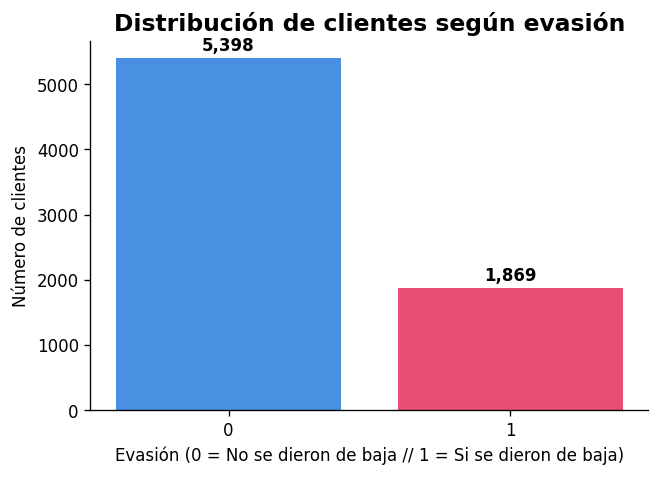

In [375]:
plt.figure(figsize=(6,4), dpi=120)
bars = plt.bar(churn_counts.index.astype(str),churn_counts.values,color=["#4A90E2", "#E94E77"], width=0.8)
plt.title("Distribución de clientes según evasión", fontsize=14, weight="bold")
plt.xlabel("Evasión (0 = No se dieron de baja // 1 = Si se dieron de baja)", fontsize=10)
plt.ylabel("Número de clientes", fontsize=10)

for spine in ["top", "right",]:
    plt.gca().spines[spine].set_visible(False)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,yval + 50,f"{yval:,}", ha="center", va="bottom", fontsize=10, weight="bold")
plt.show()

## **Recuento de evasión por variables categóricas**

Ahora, exploraremos cómo se distribuye la evasión según variables categóricas, como género, tipo de contrato, método de pago, entre otras.

Este análisis puede revelar patrones interesantes, por ejemplo, si los clientes de ciertos perfiles tienen una mayor tendencia a cancelar el servicio, lo que ayudará a orientar acciones estratégicas.

In [382]:
categorical_vars = ["gender", "contract", "paymentmethod", "internetservice"]

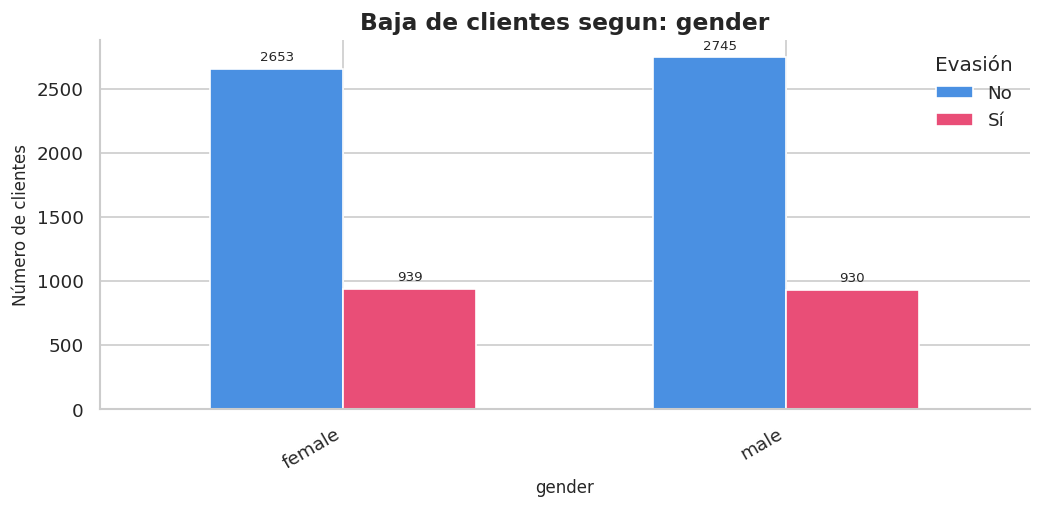

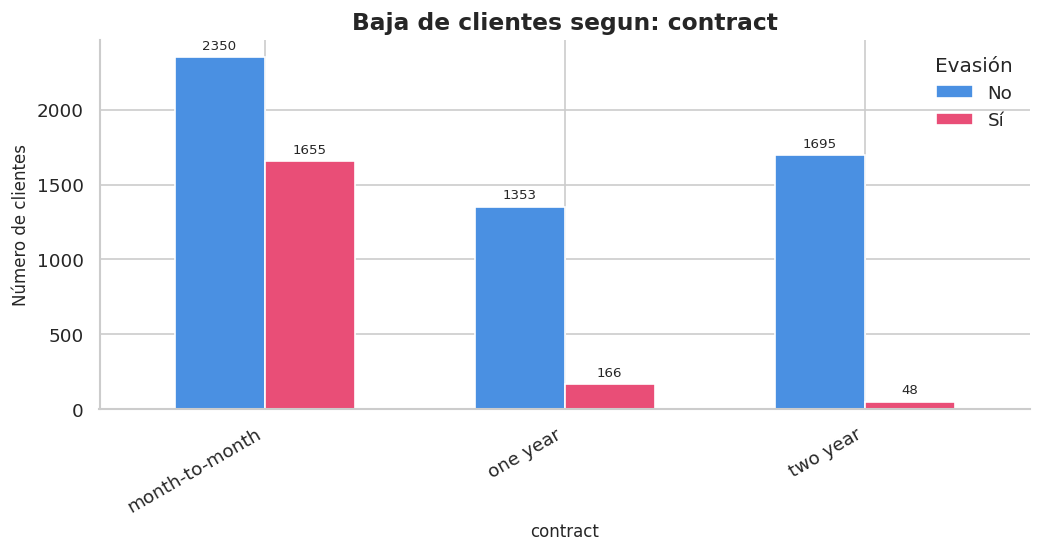

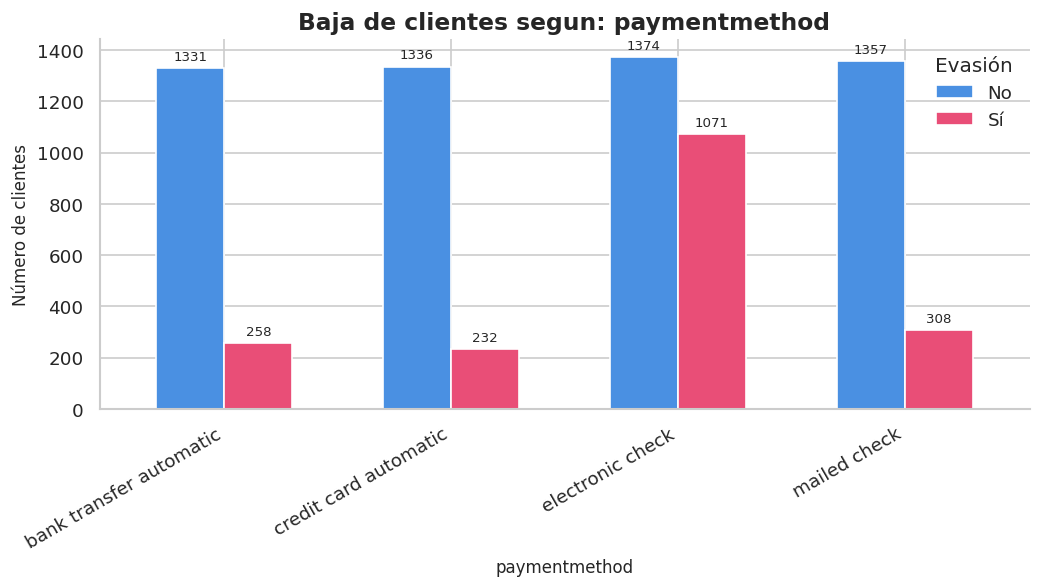

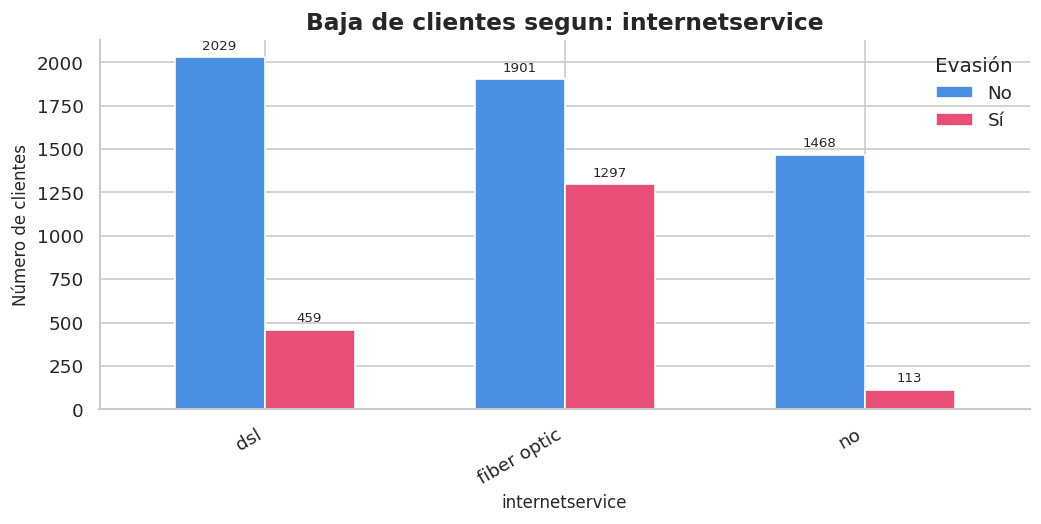

In [392]:
colors = ["#4A90E2", "#E94E77"]
for var in categorical_vars:
    plt.figure(figsize=(10,4), dpi=120)
    counts = pd.crosstab(data_norm[var], data_norm["churn"])
    counts.plot(kind="bar", stacked=False, color=colors, width=0.6, ax=plt.gca())
    plt.title(f"Baja de clientes segun: {var}", fontsize=14, weight="bold")
    plt.xlabel(var, fontsize=10)
    plt.ylabel("Número de clientes", fontsize=10)
    plt.xticks(rotation=30, ha="right")
    plt.legend(title="Evasión", labels=["No", "Sí"], loc="upper right")
    for spine in ["top", "right"]:
        plt.gca().spines[spine].set_visible(False)
    for container in plt.gca().containers:
        plt.bar_label(container, fmt="%.0f", fontsize=8, padding=3)

    plt.show()

## **Conteo de evasión por variables numéricas**

In [387]:
import seaborn as sns

In [395]:
numeric_vars = ["charges_monthly", "charges_total", "charges_daily", "tenure"]

In [396]:
data_norm["churn"] = data_norm["churn"].astype(int)

In [400]:
data_norm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerid        7267 non-null   object 
 1   churn             7267 non-null   int64  
 2   gender            7267 non-null   object 
 3   seniorcitizen     7267 non-null   int64  
 4   partner           7267 non-null   int64  
 5   dependents        7267 non-null   int64  
 6   tenure            7267 non-null   int64  
 7   phoneservice      7267 non-null   int64  
 8   multiplelines     7267 non-null   int64  
 9   internetservice   7267 non-null   object 
 10  onlinesecurity    7267 non-null   int64  
 11  onlinebackup      7267 non-null   int64  
 12  deviceprotection  7267 non-null   int64  
 13  techsupport       7267 non-null   int64  
 14  streamingtv       7267 non-null   int64  
 15  streamingmovies   7267 non-null   int64  
 16  contract          7267 non-null   object 


In [414]:
data_norm["churn"] = data_norm["churn"].astype(str).replace({"0": "No", "1": "Sí"})

In [420]:
var_labels = {
    "charges_monthly": "Cargo mensual",
    "charges_total": "Cargo total",
    "charges_daily": "Cargo diario",
    "tenure": "Tiempo de permanencia (meses)"
}

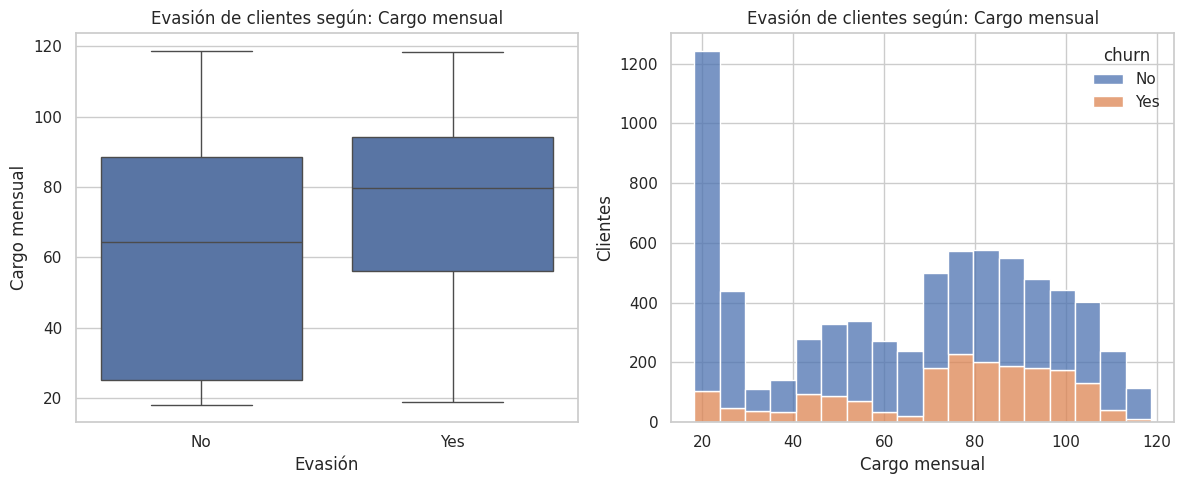

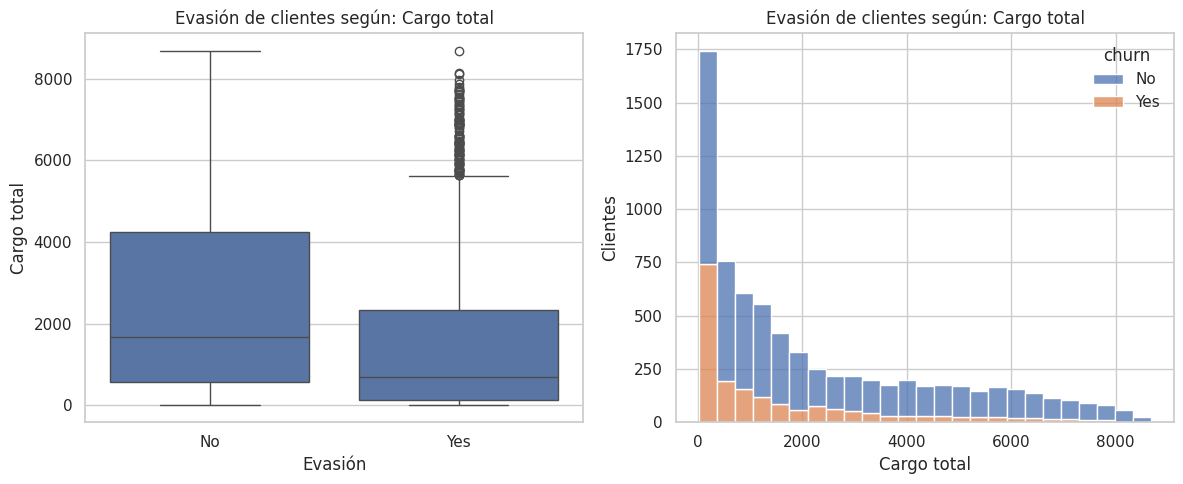

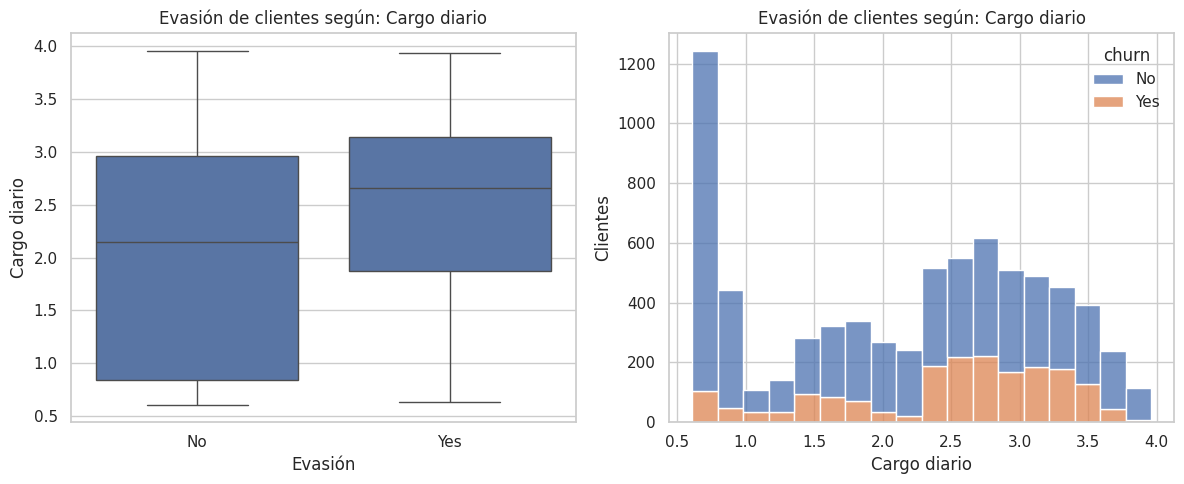

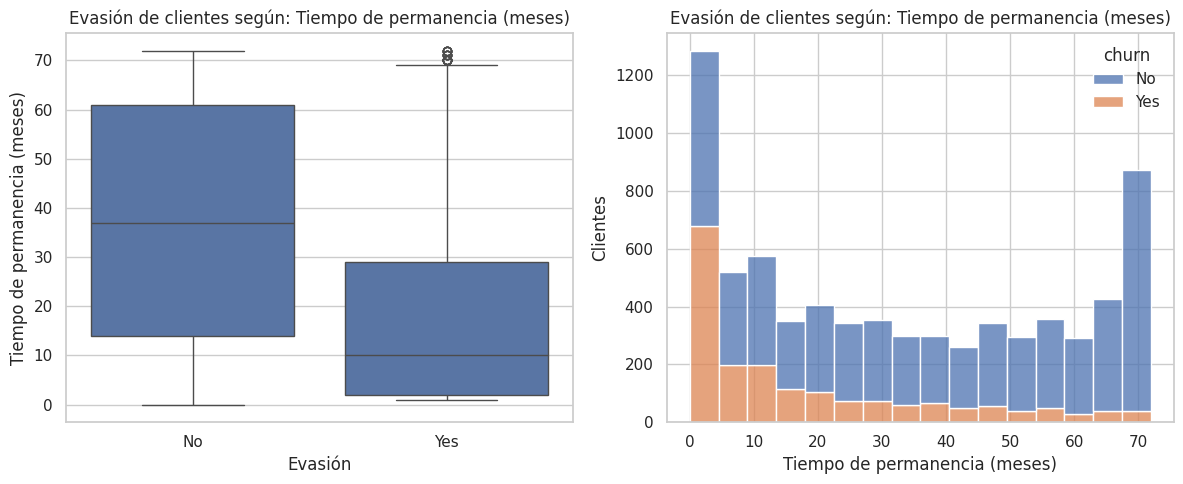

In [422]:
for var in var_labels:
    plt.figure(figsize=(12,5))

    # Boxplot
    plt.subplot(1,2,1)
    sns.boxplot(data=data_norm,x="churn",y=var,)
    plt.title(f"Evasión de clientes según: {var_labels[var]}")
    plt.xlabel("Evasión")
    plt.ylabel(var_labels[var])

    # Histograma
    plt.subplot(1,2,2)
    sns.histplot(data=data_norm,x=var,hue="churn",multiple="stack",)
    plt.title(f"Evasión de clientes según: {var_labels[var]}")
    plt.xlabel(var_labels[var])
    plt.ylabel("Clientes")

    plt.tight_layout()
    plt.show()

#📄Informe final

## 🔹 Introducción:

El objetivo principal de este análisis es comprender los factores que contribuyen a la evasión de clientes (Churn) en TelecomX. La evasión de clientes es un desafío significativo para las empresas de telecomunicaciones, ya que la adquisición de nuevos clientes suele ser más costosa que la retención de los existentes. Al identificar los patrones y las razones detrás de la evasión, TelecomX podrá implementar estrategias efectivas para reducirla y mejorar la satisfacción del cliente.

Este informe detalla el proceso de extracción, transformación y carga de los datos, seguido de un análisis exploratorio para identificar patrones clave relacionados con el Churn. Finalmente, se presentan conclusiones, insights y recomendaciones estratégicas basadas en los hallazgos.

## 🔹 Limpieza y Tratamiento de Datos:

El proceso de preparación de los datos para el análisis incluyó las siguientes etapas:

1.  **Extracción de Datos:** Los datos fueron cargados desde un archivo JSON alojado en una URL ([Celda 1--uPM88l7JH](https://colab.research.google.com/drive/1p_z_q3_p0Y5S7f7l0k9j1l2l8m8d8c8c?usp=drive_url#scrollTo=1--uPM88l7JH)). Se realizó una inspección inicial para entender la estructura y el contenido del dataset ([Celdas jRGvIhJCj1Kf, MsFFUUchlRgD, a9RkmvDElR5M, FatWYNXHlSAE](https://colab.research.google.com/drive/1p_z_q3_p0Y5S7f7l0k9j1l2l8m8d8c8c?usp=drive_url#scrollTo=jRGvIhJCj1Kf)).

2.  **Normalización de Datos:** Se normalizaron las columnas anidadas 'customer', 'phone', 'internet' y 'account' para aplanar la estructura del DataFrame y facilitar el acceso a la información ([Celdas gBhJ59z4sAnU, qlYoWiH9sAf-, GVJYX57MsAW_, eKT8auKosAMI](https://colab.research.google.com/drive/1p_z_q3_p0Y5S7f7l0k9j1l2l8m8d8c8c?usp=drive_url#scrollTo=gBhJ59z4sAnU)). Posteriormente, se concatenaron estas columnas normalizadas con las columnas 'customerID' y 'Churn' del DataFrame original para crear un único DataFrame normalizado ([Celda bsm-WTLjmHvt](https://colab.research.google.com/drive/1p_z_q3_p0Y5S7f7l0k9j1l2l8m8d8c8c?usp=drive_url#scrollTo=bsm-WTLjmHvt)).

3.  **Manejo de Inconsistencias:**
    *   Se uniformizaron los nombres de las columnas a minúsculas y se reemplazaron los puntos por guiones bajos para una mayor consistencia ([Celda i0gkUjzm59W9](https://colab.research.google.com/drive/1p_z_q3_p0Y5S7f7l0k9j1l2l8m8d8c8c?usp=drive_url#scrollTo=i0gkUjzm59W9)).
    *   Se convirtió la columna 'charges_total' a tipo numérico, manejando los valores vacíos como nulos ([Celdas 3dZ44qNQ0OZC, 0i8MepXswRR8](https://colab.research.google.com/drive/1p_z_q3_p0Y5S7f7l0k9j1l2l8m8d8c8c?usp=drive_url#scrollTo=3dZ44qNQ0OZC)).
    *   Se convirtieron los valores de las columnas de tipo 'object' a minúsculas para estandarizar las entradas de texto ([Celdas RmxnrBJ911bK, uZJ678c311Qq](https://colab.research.google.com/drive/1p_z_q3_p0Y5S7f7l0k9j1l2l8m8d8c8c?usp=drive_url#scrollTo=RmxnrBJ911bK)).
    *   Se reemplazaron los valores "no phone service" y "no internet service" por "no" en las columnas correspondientes para simplificar las categorías ([Celdas dwUd7WsY8jwv, LQQ8dv3h8j4H, -VOL41-J8j73](https://colab.research.google.com/drive/1p_z_q3_p0Y5S7f7l0k9j1l2l8m8d8c8c?usp=drive_url#scrollTo=dwUd7WsY8jwv)).
    *   Se eliminaron paréntesis de la columna 'paymentmethod' ([Celda mKS-WsWKD7IW](https://colab.research.google.com/drive/1p_z_q3_p0Y5S7f7l0k9j1l2l8m8d8c8c?usp=drive_url#scrollTo=mKS-WsWKD7IW)).
    *   Se imputaron los valores nulos en la columna 'charges_total' utilizando el valor de 'charges_monthly' multiplicado por 12 ([Celda yUqOmFtVI5kB](https://colab.research.google.com/drive/1p_z_q3_p0Y5S7f7l0k9j1l2l8m8d8c8c?usp=drive_url#scrollTo=yUqOmFtVI5kB)).

4.  **Creación de Columna Derivada:** Se creó la columna 'charges_daily' calculando el cargo diario a partir del cargo mensual ([Celda rkfTSIN_D7_P](https://colab.research.google.com/drive/1p_z_q3_p0Y5S7f7l0k9j1l2l8m8d8c8c?usp=drive_url#scrollTo=rkfTSIN_D7_P)).

5.  **Estandarización de Datos:** Se convirtieron los valores categóricos binarios ("yes", "no") a valores numéricos (1, 0) en las columnas especificadas para facilitar el análisis cuantitativo ([Celdas BcSzmht8G8NB, HEBCInVOG8E0](https://colab.research.google.com/drive/1p_z_q3_p0Y5S7f7l0k9j1l2l8m8d8c8c?usp=drive_url#scrollTo=BcSzmht8G8NB)).

## 🔹 Análisis Exploratorio de Datos:

El análisis exploratorio de datos nos permitió identificar patrones y relaciones clave dentro del dataset, centrándonos en la variable objetivo "churn".

1.  **Análisis Descriptivo:** Se calcularon estadísticas descriptivas ([Celda 1jgUnLqTmPdd](https://colab.research.google.com/drive/1p_z_q3_p0Y5S7f7l0k9j1l2l8m8d8c8c?usp=drive_url#scrollTo=1jgUnLqTmPdd)) para obtener una visión general de la distribución de las variables numéricas como `tenure`, `charges_monthly`, y `charges_total`. Esto nos dio una idea de los valores típicos, la dispersión y los rangos de estas variables.

2.  **Distribución de Evasión (Churn):** Visualizamos la distribución de la variable "churn" ([Celdas c3lNyD6RKypz, G1JSWCL1Ky6N, cd1hmgliNBrx](https://colab.research.google.com/drive/1p_z_q3_p0Y5S7f7l0k9j1l2l8m8d8c8c?usp=drive_url#scrollTo=c3lNyD6RKypz)). El gráfico de barras mostró claramente la proporción de clientes que se dieron de baja (churn = 1) en comparación con los que no se dieron de baja (churn = 0). Esta visualización es crucial para entender el desbalance de clases en el dataset.

3.  **Recuento de Evasión por Variables Categóricas:** Exploramos la relación entre la evasión y variables categóricas como `gender`, `contract`, `paymentmethod`, y `internetservice` ([Celdas wwtANXyzNCUJ, s2n3BvHkUmLH](https://colab.research.google.com/drive/1p_z_q3_p0Y5S7f7l0k9j1l2l8m8d8c8c?usp=drive_url#scrollTo=wwtANXyzNCUJ)). Los gráficos de barras agrupadas revelaron cómo la tasa de evasión varía entre las diferentes categorías de cada variable. Por ejemplo, se observó una mayor tasa de evasión en clientes con contratos mes a mes y aquellos que utilizan el método de pago de cheque electrónico.

4.  **Conteo de Evasión por Variables Numéricas:** Analizamos la distribución de variables numéricas (`charges_monthly`, `charges_total`, `charges_daily`, `tenure`) en relación con la evasión utilizando boxplots e histogramas ([Celdas 6pZsCDHzZ1oK, OLV0kPBhb1rT](https://colab.research.google.com/drive/1p_z_q3_p0Y5S7f7l0k9j1l2l8m8d8c8c?usp=drive_url#scrollTo=6pZsCDHzZ1oK)). Los boxplots nos ayudaron a visualizar las diferencias en la mediana y la dispersión de estas variables entre los clientes que se dieron de baja y los que no. Los histogramas apilados mostraron la distribución de estas variables para cada grupo de evasión, permitiéndonos identificar posibles umbrales o rangos de valores asociados con una mayor propensión a la evasión. Por ejemplo, se notó que los clientes con menor tiempo de permanencia (`tenure`) y mayores cargos mensuales (`charges_monthly`) o diarios (`charges_daily`) tienden a tener una mayor tasa de evasión.

## 🔹 Conclusiones e Insights:

Basado en el análisis exploratorio de datos, se pueden extraer las siguientes conclusiones e insights clave para TelecomX:

*   **Alta Tasa de Evasión en Contratos Mes a Mes:** Los clientes con contratos mes a mes presentan una tasa de evasión significativamente mayor en comparación con aquellos con contratos de uno o dos años. Esto sugiere que la falta de un compromiso a largo plazo es un factor importante que contribuye al Churn.

*   **Métodos de Pago y Evasión:** Los clientes que utilizan métodos de pago como el cheque electrónico tienen una mayor propensión a la evasión. Esto podría estar relacionado con la facilidad para cancelar el servicio o con la demografía de los usuarios de este método de pago.

*   **Servicio de Internet Fibra Óptica y Evasión:** Aunque el servicio de fibra óptica es a menudo percibido como superior, los clientes con este tipo de conexión muestran una tasa de evasión considerable. Esto podría indicar problemas con la calidad del servicio, la estabilidad de la conexión o las expectativas del cliente.

*   **Tiempo de Permanencia y Evasión:** Existe una clara relación inversa entre el tiempo de permanencia (tenure) y la evasión. Los clientes con menor antigüedad en la empresa tienen una mayor probabilidad de darse de baja. Esto resalta la importancia de las estrategias de retención temprana.

*   **Cargos Mensuales y Evasión:** Los clientes con cargos mensuales más altos tienden a tener una mayor tasa de evasión. Esto podría deberse a que perciben que el costo no justifica el valor del servicio, o a que son más sensibles a los aumentas de precio.

Estos insights sugieren que la evasión de clientes en TelecomX no se debe a un único factor, sino a una combinación de variables relacionadas con el tipo de contrato, método de pago, servicio de internet, tiempo de permanencia y costos. La comprensión de estas relaciones es fundamental para desarrollar estrategias de retención dirigidas y efectivas.

## 🔹 Recomendaciones:

Basado en los hallazgos de este análisis, se proponen las siguientes recomendaciones estratégicas para ayudar a TelecomX a reducir la evasión de clientes:

*   **Fomentar Contratos a Largo Plazo:** Implementar incentivos atractivos para que los clientes opten por contratos de uno o dos años en lugar de contratos mes a mes. Esto podría incluir descuentos en la tarifa mensual, beneficios adicionales o promociones exclusivas para contratos de mayor duración.

*   **Evaluar Métodos de Pago:** Investigar por qué los clientes que utilizan cheque electrónico tienen una mayor tasa de evasión. Podría ser necesario ofrecer alternativas de pago más convenientes o seguras, o comunicar de manera más efectiva los beneficios de otros métodos de pago.

*   **Mejorar la Experiencia del Cliente con Fibra Óptica:** A pesar de ser un servicio premium, la alta tasa de evasión en clientes de fibra óptica sugiere posibles problemas. Se recomienda investigar la calidad y estabilidad del servicio, así como gestionar las expectativas del cliente desde el inicio. Un soporte técnico proactivo y eficiente podría ser clave.

*   **Implementar Estrategias de Retención Temprana:** Dado que los clientes con menor tiempo de permanencia son más propensos a la evasión, es crucial enfocar esfuerzos en la retención durante los primeros meses de servicio. Esto podría incluir programas de onboarding personalizados, seguimiento proactivo para resolver problemas iniciales y ofertas especiales para afianzar la relación.

*   **Optimizar la Estructura de Cargos:** Analizar la relación entre los cargos mensuales/diarios y la evasión para identificar posibles puntos de fricción en la percepción del valor. Considerar la posibilidad de ofrecer planes más flexibles, opciones de personalización o comunicar de manera más transparente el desglose de los cargos.

*   **Segmentación de Clientes:** Utilizar los insights del análisis para segmentar a los clientes en grupos de riesgo de evasión (por ejemplo, clientes con contrato mes a mes, altos cargos, menor tiempo de permanencia, etc.). Esto permitirá diseñar campañas de retención dirigidas y personalizadas para cada segmento.

*   **Monitoreo Continuo:** Establecer un sistema de monitoreo continuo de los indicadores clave de evasión y realizar análisis periódicos para identificar nuevas tendencias y evaluar la efectividad de las estrategias de retención implementadas.